## 1. Importación de Librerías

In [2]:
# ===== MANIPULACIÓN DE DATOS =====
import pandas as pd               # Para trabajar con tablas de datos
import numpy as np                # Para operaciones matemáticas y arrays

# ===== VISUALIZACIÓN =====
import matplotlib.pyplot as plt   # Gráficos básicos
import seaborn as sns             # Gráficos estadísticos elegantes

# Configuración de estilo
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# ===== PREPROCESAMIENTO =====
from sklearn.model_selection import train_test_split  # Dividir datos train/test
from sklearn.preprocessing import StandardScaler      # Normalizar variables numéricas
from sklearn.preprocessing import LabelEncoder        # Convertir categorías a números

# ===== MODELO =====
from sklearn.linear_model import LogisticRegression   # Regresión Logística

# ===== EVALUACIÓN =====
from sklearn.metrics import (
    confusion_matrix,           # Matriz de confusión
    classification_report,      # Reporte completo (precision, recall, f1)
    roc_auc_score,              # Área bajo la curva ROC
    roc_curve,                  # Puntos para graficar curva ROC
    accuracy_score              # Exactitud (accuracy)
)

# ===== WARNINGS =====
import warnings
warnings.filterwarnings('ignore')


# ===== Cargar datos
from cargar_datos import cargarDatos

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2. Carga y Exploración Inicial de Datos

In [3]:
# Carga de los datos
df = cargarDatos()

# vista previa de los datos
print(df.head())

       tipo_credito      fecha_prestamo  capital_prestado  plazo_meses  \
0                 7 2024-12-21 11:31:35         3692160.0           10   
1                 4 2025-04-22 09:47:35          840000.0            6   
2                 9 2026-01-08 12:22:40         5974028.4           10   
3                 4 2025-08-04 12:04:10         1671240.0            6   
4                 9 2025-04-26 11:24:26         2781636.0           11   
...             ...                 ...               ...          ...   
10758             9 2025-01-19 16:18:28         2414886.0           10   
10759             4 2025-01-10 16:40:21         2916000.0           24   
10760             4 2025-06-19 14:28:47         4249200.0           36   
10761             9 2025-03-02 11:53:41         1283307.6           10   
10762             4 2024-12-08 12:46:03         3915000.0           12   

       edad_cliente   tipo_laboral  salario_cliente  total_otros_prestamos  \
0                42  Independient

In [4]:
# Información detallada de columnas
print("\n📋 INFORMACIÓN DE LAS COLUMNAS")
print("=" * 70)
df.info()



📋 INFORMACIÓN DE LAS COLUMNAS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 23 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[ns]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  object        
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  floa

In [5]:
# Verificar valores nulos
print("\n🔎 VERIFICACIÓN DE VALORES NULOS")
print("=" * 70)
null_counts = df.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "✅ No hay valores nulos en el dataset")


🔎 VERIFICACIÓN DE VALORES NULOS
puntaje_datacredito                 6
saldo_mora                        156
saldo_total                       156
saldo_principal                   405
saldo_mora_codeudor               590
promedio_ingresos_datacredito    2930
tendencia_ingresos               2932
dtype: int64


In [6]:
# Verificar duplicados
duplicados = df.duplicated().sum()
print(f"\n🔄 DUPLICADOS: {duplicados}")
if duplicados == 0:
    print("✅ No hay registros duplicados")


🔄 DUPLICADOS: 0
✅ No hay registros duplicados


### Imputación de datos

In [7]:


# Configuración
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# ============================================================================
# Limpia datos para EDA
# ============================================================================

def limpiar_datos_eda(df):
    """Limpia datos para EDA con corrección de edades y puntajes"""
    df_clean = df.copy()
    
    print("🔍 INICIANDO LIMPIEZA DE DATOS...")
    print("="*60)
    
    # ===== 1. CORREGIR EDADES ANÓMALAS =====
    if 'edad_cliente' in df_clean.columns:
        edades_menores = df_clean[df_clean['edad_cliente'] < 18].shape[0]
        edades_mayores = df_clean[df_clean['edad_cliente'] > 110].shape[0]
        
        if edades_menores > 0 or edades_mayores > 0:
            print(f"🔹 Corrigiendo edades anómalas:")
            print(f"   • Edades < 18 años: {edades_menores}")
            print(f"   • Edades > 110 años: {edades_mayores}")
            
            # Calcular edad mediana en rango normal (18-80 años)
            edad_mediana = df_clean[(df_clean['edad_cliente'] >= 18) & 
                                    (df_clean['edad_cliente'] <= 80)]['edad_cliente'].median()
            
            # Reemplazar edades anómalas con la mediana
            df_clean.loc[df_clean['edad_cliente'] < 18, 'edad_cliente'] = round(edad_mediana)
            df_clean.loc[df_clean['edad_cliente'] > 110, 'edad_cliente'] = round(edad_mediana)
            
            print(f"   ✅ Edades corregidas con mediana: {round(edad_mediana)} años")
    
    # ===== 2. CORREGIR PUNTAJES CREDITICIOS NEGATIVOS =====
    if 'puntaje_datacredito' in df_clean.columns:
        puntajes_negativos = df_clean[df_clean['puntaje_datacredito'] < 0].shape[0]
        if puntajes_negativos > 0:
            print(f"\n🔹 Corrigiendo {puntajes_negativos} puntajes crediticios negativos...")
            
            # Calcular puntaje mínimo aceptable (percentil 1 para evitar outliers)
            puntaje_minimo = df_clean[df_clean['puntaje_datacredito'] >= 0]['puntaje_datacredito'].quantile(0.01)
            puntaje_mediana = df_clean[df_clean['puntaje_datacredito'] >= 0]['puntaje_datacredito'].median()
            
            # Opción 1: Reemplazar negativos con 0
            df_clean.loc[df_clean['puntaje_datacredito'] < 0, 'puntaje_datacredito'] = 0
            
            # Opción 2: Reemplazar negativos con la mediana (descomentar si prefieres esta opción)
            # df_clean.loc[df_clean['puntaje_datacredito'] < 0, 'puntaje_datacredito'] = round(puntaje_mediana)
            
            print(f"   ✅ Puntajes negativos convertidos a 0")
            print(f"   📊 Mediana de puntajes positivos: {round(puntaje_mediana)}")
    
    # ===== 3. CORREGIR PUNTAJE GENERAL NEGATIVO =====
    if 'puntaje' in df_clean.columns:
        puntaje_negativos = df_clean[df_clean['puntaje'] < 0].shape[0]
        if puntaje_negativos > 0:
            print(f"\n🔹 Corrigiendo {puntaje_negativos} puntajes generales negativos...")
            df_clean.loc[df_clean['puntaje'] < 0, 'puntaje'] = 0
            print(f"   ✅ Puntajes generales negativos convertidos a 0")
    
    # ===== 4. CORREGIR SALARIOS NEGATIVOS =====
    if 'salario_cliente' in df_clean.columns:
        salarios_negativos = df_clean[df_clean['salario_cliente'] < 0].shape[0]
        if salarios_negativos > 0:
            print(f"\n🔹 Corrigiendo {salarios_negativos} salarios negativos...")
            df_clean.loc[df_clean['salario_cliente'] < 0, 'salario_cliente'] = 0
            print(f"   ✅ Salarios negativos convertidos a 0")
    
    # ===== 5. CORREGIR CAPITAL PRESTADO NEGATIVO =====
    if 'capital_prestado' in df_clean.columns:
        capital_negativo = df_clean[df_clean['capital_prestado'] < 0].shape[0]
        if capital_negativo > 0:
            print(f"\n🔹 Corrigiendo {capital_negativo} capitales prestados negativos...")
            df_clean.loc[df_clean['capital_prestado'] < 0, 'capital_prestado'] = df_clean['capital_prestado'].abs()
            print(f"   ✅ Capitales negativos convertidos a positivos")
    
    # ===== 6. CORREGIR PLAZOS ANÓMALOS =====
    if 'plazo_meses' in df_clean.columns:
        plazos_extremos = df_clean[(df_clean['plazo_meses'] < 1) | (df_clean['plazo_meses'] > 360)].shape[0]
        if plazos_extremos > 0:
            print(f"\n🔹 Corrigiendo {plazos_extremos} plazos anómalos...")
            plazo_mediana = df_clean[(df_clean['plazo_meses'] >= 1) & 
                                     (df_clean['plazo_meses'] <= 120)]['plazo_meses'].median()
            df_clean.loc[df_clean['plazo_meses'] < 1, 'plazo_meses'] = round(plazo_mediana)
            df_clean.loc[df_clean['plazo_meses'] > 360, 'plazo_meses'] = round(plazo_mediana)
            print(f"   ✅ Plazos corregidos con mediana: {round(plazo_mediana)} meses")
    
    # ===== 7. IMPUTAR NULOS NUMÉRICOS CON MEDIANA =====
    print(f"\n🔹 Imputando valores nulos...")
    num_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
    for col in num_cols:
        if df_clean[col].isnull().any():
            nulos = df_clean[col].isnull().sum()
            df_clean[col].fillna(df_clean[col].median(), inplace=True)
            print(f"   • Columna '{col}': {nulos} nulos imputados con mediana")
    
    # ===== 8. IMPUTAR NULOS CATEGÓRICOS CON MODA =====
    cat_cols = df_clean.select_dtypes(include=['object']).columns
    for col in cat_cols:
        if df_clean[col].isnull().any():
            nulos = df_clean[col].isnull().sum()
            df_clean[col].fillna(df_clean[col].mode()[0], inplace=True)
            print(f"   • Columna '{col}': {nulos} nulos imputados con moda")
    
    print("\n" + "="*60)
    print("✅ LIMPIEZA DE DATOS COMPLETADA")
    print("="*60)
    
    return df_clean

### termina bloque de prueba

### Desarrollo del EDA

In [8]:
# ============================================================================
# CARGAR Y LIMPIAR DATOS
# ============================================================================

df_clean = limpiar_datos_eda(df)

print("✅ DATOS LIMPIOS PARA EDA")
print(f"Shape: {df_clean.shape}")
print(f"Nulos: {df_clean.isnull().sum().sum()}")

🔍 INICIANDO LIMPIEZA DE DATOS...
🔹 Corrigiendo edades anómalas:
   • Edades < 18 años: 0
   • Edades > 110 años: 150
   ✅ Edades corregidas con mediana: 42 años

🔹 Corrigiendo 1 puntajes crediticios negativos...
   ✅ Puntajes negativos convertidos a 0
   📊 Mediana de puntajes positivos: 791

🔹 Corrigiendo 135 puntajes generales negativos...
   ✅ Puntajes generales negativos convertidos a 0

🔹 Imputando valores nulos...
   • Columna 'puntaje_datacredito': 6 nulos imputados con mediana
   • Columna 'saldo_mora': 156 nulos imputados con mediana
   • Columna 'saldo_total': 156 nulos imputados con mediana
   • Columna 'saldo_principal': 405 nulos imputados con mediana
   • Columna 'saldo_mora_codeudor': 590 nulos imputados con mediana
   • Columna 'promedio_ingresos_datacredito': 2930 nulos imputados con mediana
   • Columna 'tendencia_ingresos': 2932 nulos imputados con moda

✅ LIMPIEZA DE DATOS COMPLETADA
✅ DATOS LIMPIOS PARA EDA
Shape: (10763, 23)
Nulos: 0


In [9]:
# Estadísticas descriptivas
print("\n📈 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 70)
display(df_clean.describe())

print("\n📊 RESUMEN EJECUTIVO - ANÁLISIS CREDITICIO")
print("="*60)
print(f"👤 Perfil del cliente:")
print(f"   • Edad: {df_clean['edad_cliente'].min():.0f} - {df_clean['edad_cliente'].max():.0f} años (prom: {df_clean['edad_cliente'].mean():.0f})")
print(f"   • Salario mensual: ${df_clean['salario_cliente'].median():,.0f} promedio (máx: ${df_clean['salario_cliente'].max():,.0f})")
print()
print(f"💰 Características del crédito:")
print(f"   • Monto prestado: ${df_clean['capital_prestado'].median():,.0f} (máx: ${df_clean['capital_prestado'].max():,.0f})")
print(f"   • Plazo: {df_clean['plazo_meses'].mean():.0f} meses promedio")
print(f"   • Cuota mensual: ${df_clean['cuota_pactada'].median():,.0f} promedio")
print()
print(f"📈 Comportamiento crediticio:")
print(f"   • Puntaje DataCrédito: {df_clean['puntaje_datacredito'].mean():.0f} (rango: {df_clean['puntaje_datacredito'].min():.0f} - {df_clean['puntaje_datacredito'].max():.0f})")
print(f"   • Pago a tiempo: {df_clean['Pago_atiempo'].mean()*100:.1f}% de cumplimiento")
print(f"   • Mora: {df_clean[df_clean['saldo_mora'] > 0].shape[0]} clientes ({ (df_clean[df_clean['saldo_mora'] > 0].shape[0]/len(df_clean))*100:.1f}%) con saldo en mora")
print(f"   • Saldo promedio en mora: ${df_clean[df_clean['saldo_mora'] > 0]['saldo_mora'].mean():,.0f} (máx: ${df_clean['saldo_mora'].max():,.0f})")
print()
print(f"🏦 Historial crediticio:")
print(f"   • Créditos sector financiero: {df_clean['creditos_sectorFinanciero'].mean():.1f} en promedio")
print(f"   • Créditos sector cooperativo: {df_clean['creditos_sectorCooperativo'].mean():.1f} en promedio")
print(f"   • Créditos sector real: {df_clean['creditos_sectorReal'].mean():.1f} en promedio")


📈 ESTADÍSTICAS DESCRIPTIVAS


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,...,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo
count,10763.000000,10763,1.076300e+04,10763.000000,10763.000000,1.076300e+04,1.076300e+04,1.076300e+04,10763.000000,10763.000000,...,10763.000000,10763.000000,1.076300e+04,1.076300e+04,10763.000000,10763.000000,10763.000000,10763.000000,1.076300e+04,10763.000000
mean,5.411131,2025-04-16 23:06:02.111121664,2.434315e+06,10.575583,42.833875,1.721643e+07,6.238870e+06,2.436174e+05,91.307706,780.797176,...,4.228561,7.633745,4.550607e+04,3.937144e+04,0.245749,2.779987,0.269813,1.302704,1.787194e+06,0.952523
min,4.000000,2024-11-26 09:17:04,3.600000e+05,2.000000,19.000000,0.000000e+00,0.000000e+00,2.394400e+04,0.000000,0.000000,...,0.000000,0.000000,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000
25%,4.000000,2025-01-20 17:33:07.500000,1.224831e+06,6.000000,33.000000,2.000000e+06,5.000000e+05,1.210415e+05,95.227787,757.000000,...,2.000000,0.000000,3.025000e+03,2.999000e+03,0.000000,1.000000,0.000000,0.000000,9.618850e+05,1.000000
50%,4.000000,2025-03-27 16:23:12,1.921920e+06,10.000000,42.000000,3.000000e+06,1.000000e+06,1.828630e+05,95.227787,791.000000,...,4.000000,0.000000,1.617800e+04,1.444250e+04,0.000000,2.000000,0.000000,1.000000,1.204496e+06,1.000000
75%,9.000000,2025-06-16 13:27:58,3.084840e+06,12.000000,52.000000,4.875808e+06,2.000000e+06,2.878335e+05,95.227787,825.000000,...,6.000000,0.000000,5.215600e+04,4.529700e+04,0.000000,4.000000,0.000000,2.000000,1.705770e+06,1.000000
max,68.000000,2026-04-26 18:43:52,4.144415e+07,90.000000,69.000000,2.200000e+10,6.787675e+09,3.816752e+06,95.227787,999.000000,...,29.000000,12534.000000,5.116066e+06,1.562285e+06,2145.000000,51.000000,13.000000,25.000000,3.810658e+07,1.000000
std,2.338279,NaN,1.909643e+06,6.632082,11.864169,3.554767e+08,1.184183e+08,2.104937e+05,15.618402,104.844203,...,3.064683,224.313390,1.055567e+05,7.006271e+04,21.167764,2.748807,0.716471,1.824430,1.863501e+06,0.212668



📊 RESUMEN EJECUTIVO - ANÁLISIS CREDITICIO
👤 Perfil del cliente:
   • Edad: 19 - 69 años (prom: 43)
   • Salario mensual: $3,000,000 promedio (máx: $22,000,000,000)

💰 Características del crédito:
   • Monto prestado: $1,921,920 (máx: $41,444,153)
   • Plazo: 11 meses promedio
   • Cuota mensual: $182,863 promedio

📈 Comportamiento crediticio:
   • Puntaje DataCrédito: 781 (rango: 0 - 999)
   • Pago a tiempo: 95.3% de cumplimiento
   • Mora: 55 clientes (0.5%) con saldo en mora
   • Saldo promedio en mora: $1,494 (máx: $12,534)

🏦 Historial crediticio:
   • Créditos sector financiero: 2.8 en promedio
   • Créditos sector cooperativo: 0.3 en promedio
   • Créditos sector real: 1.3 en promedio


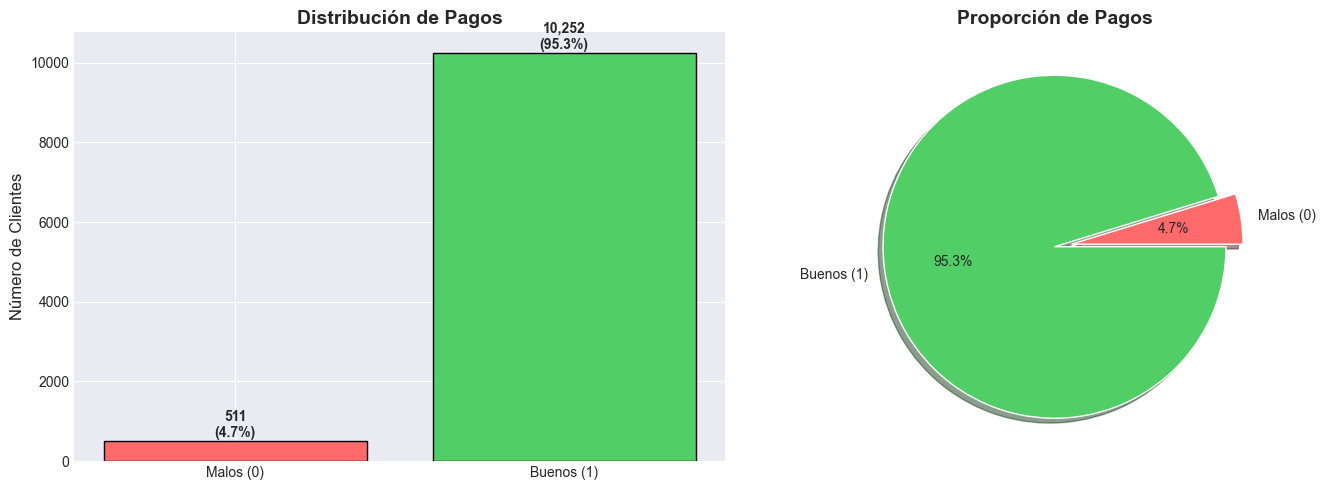

In [10]:
# Distribución del Target
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Obtener conteos y porcentajes
target_counts = df_clean['Pago_atiempo'].value_counts()
target_pct = df_clean['Pago_atiempo'].value_counts(normalize=True) * 100

# Reordenar para que primero esté 0 (Malos) y luego 1 (Buenos)
target_counts = target_counts.reindex([0, 1])
target_pct = target_pct.reindex([0, 1])


axes[0].bar(['Malos (0)', 'Buenos (1)'], target_counts.values, 
            color=['#FF6B6B', '#51CF66'], edgecolor='black')
axes[0].set_title('Distribución de Pagos', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Número de Clientes', fontsize=12)

for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 100, f'{v:,}\n({target_pct.values[i]:.1f}%)', 
                ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=['Malos (0)', 'Buenos (1)'],
           autopct='%1.1f%%', colors=['#FF6B6B', '#51CF66'], 
           explode=(0.1, 0), shadow=True)
axes[1].set_title('Proporción de Pagos', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

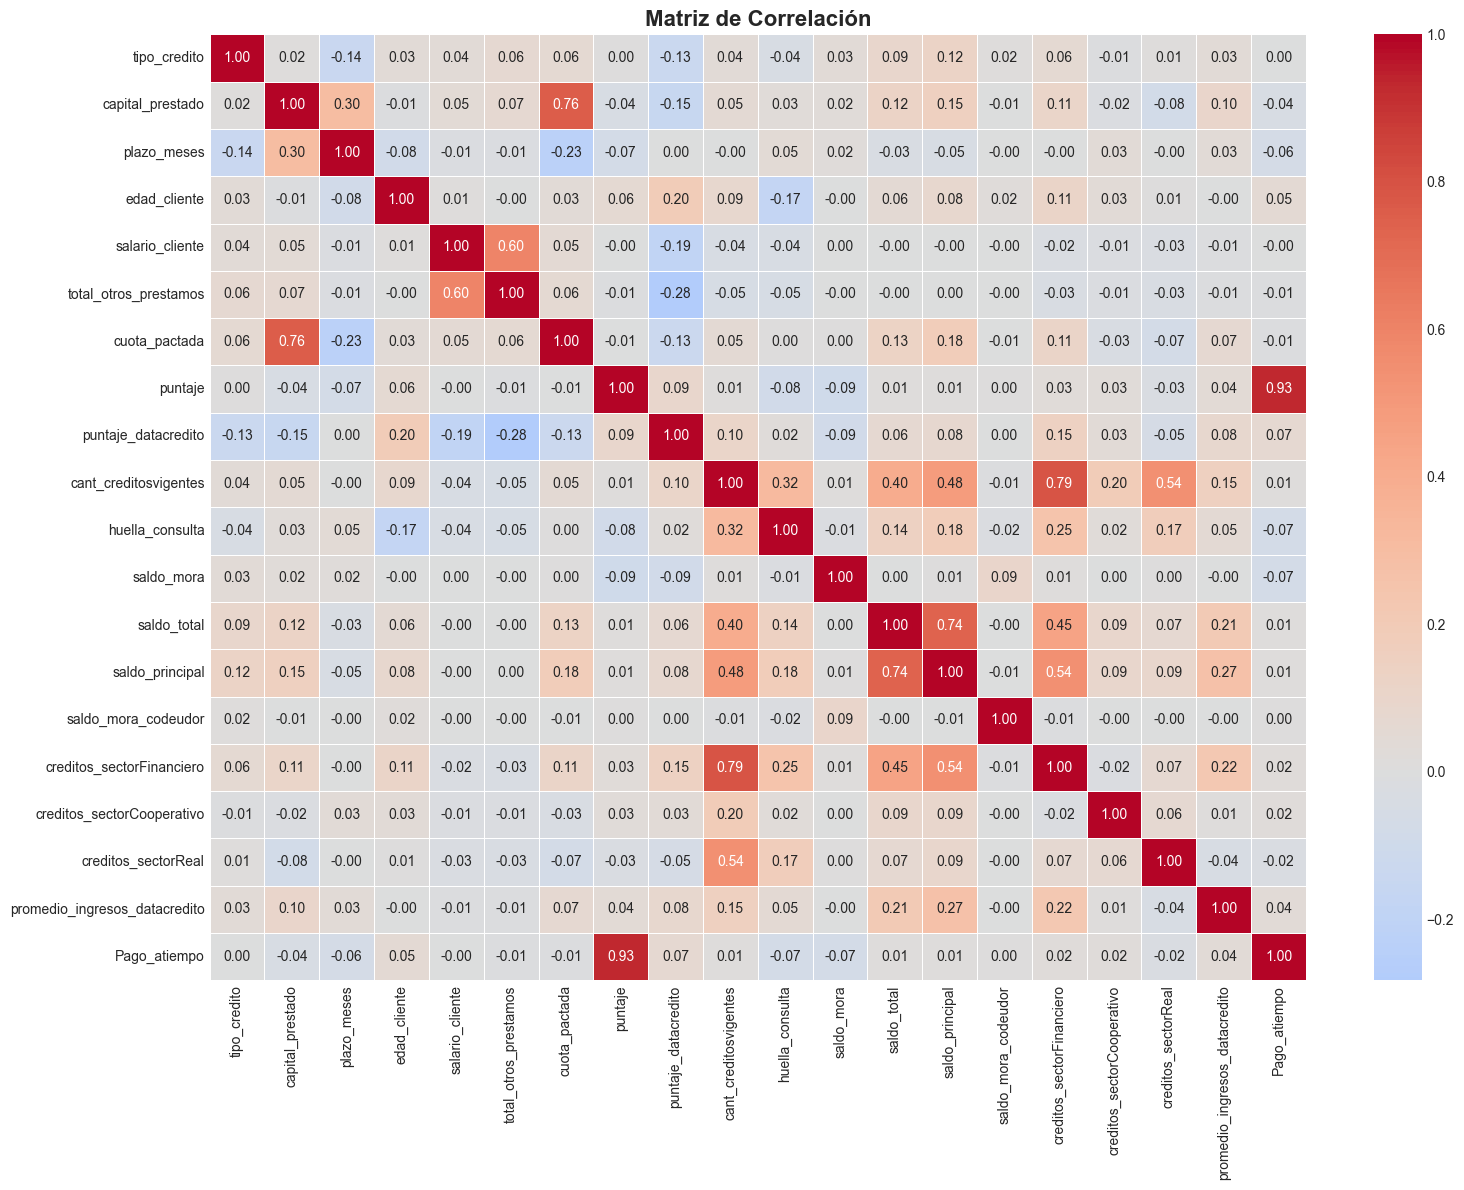

In [11]:
# Matriz de correlación
numeric_cols = df_clean.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df_clean[numeric_cols].corr()

plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, linewidths=0.5)
plt.title('Matriz de Correlación', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


📊 CORRELACIÓN CON Pago_atiempo:
   puntaje                       :   0.9337
   puntaje_datacredito           :   0.0678
   edad_cliente                  :   0.0524
   promedio_ingresos_datacredito :   0.0375
   creditos_sectorFinanciero     :   0.0214
   creditos_sectorCooperativo    :   0.0213
   saldo_total                   :   0.0146
   saldo_principal               :   0.0127
   cant_creditosvigentes         :   0.0088
   saldo_mora_codeudor           :   0.0026


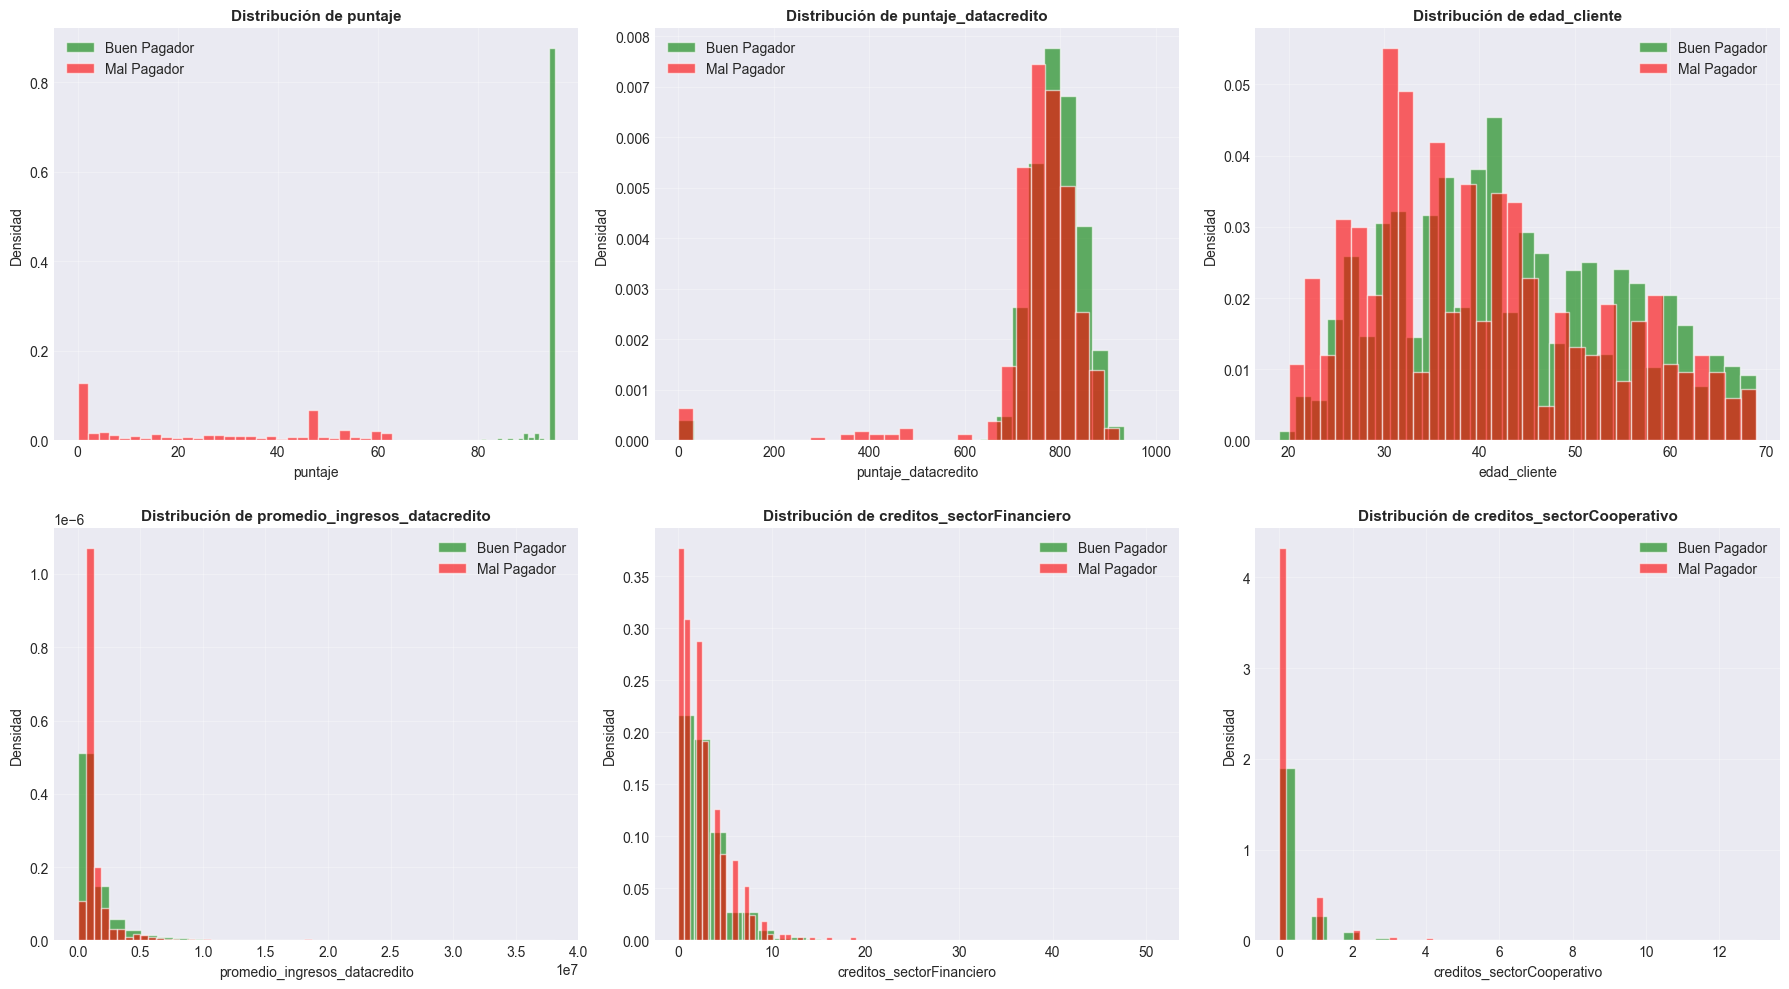

In [12]:
# 3.3 Correlación con el Target
corr_target = corr_matrix['Pago_atiempo'].drop('Pago_atiempo').sort_values(ascending=False)

print("\n📊 CORRELACIÓN CON Pago_atiempo:")
print("="*70)
for var, corr in corr_target.head(10).items():
    print(f"   {var:30s}: {corr:>8.4f}")

# 3.4 Distribución de variables clave
top_vars = corr_target.head(6).index.tolist()

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, var in enumerate(top_vars):
    if idx < len(axes):
        # Histograma por grupo
        df_bueno = df_clean[df_clean['Pago_atiempo']==1][var]
        df_malo = df_clean[df_clean['Pago_atiempo']==0][var]
        
        axes[idx].hist(df_bueno, bins=30, alpha=0.6, label='Buen Pagador', 
                      color='green', density=True)
        axes[idx].hist(df_malo, bins=30, alpha=0.6, label='Mal Pagador', 
                      color='red', density=True)
        axes[idx].set_xlabel(var, fontsize=10)
        axes[idx].set_ylabel('Densidad', fontsize=10)
        axes[idx].set_title(f'Distribución de {var}', fontsize=11, fontweight='bold')
        axes[idx].legend()
        axes[idx].grid(alpha=0.3)

plt.tight_layout()
plt.show()

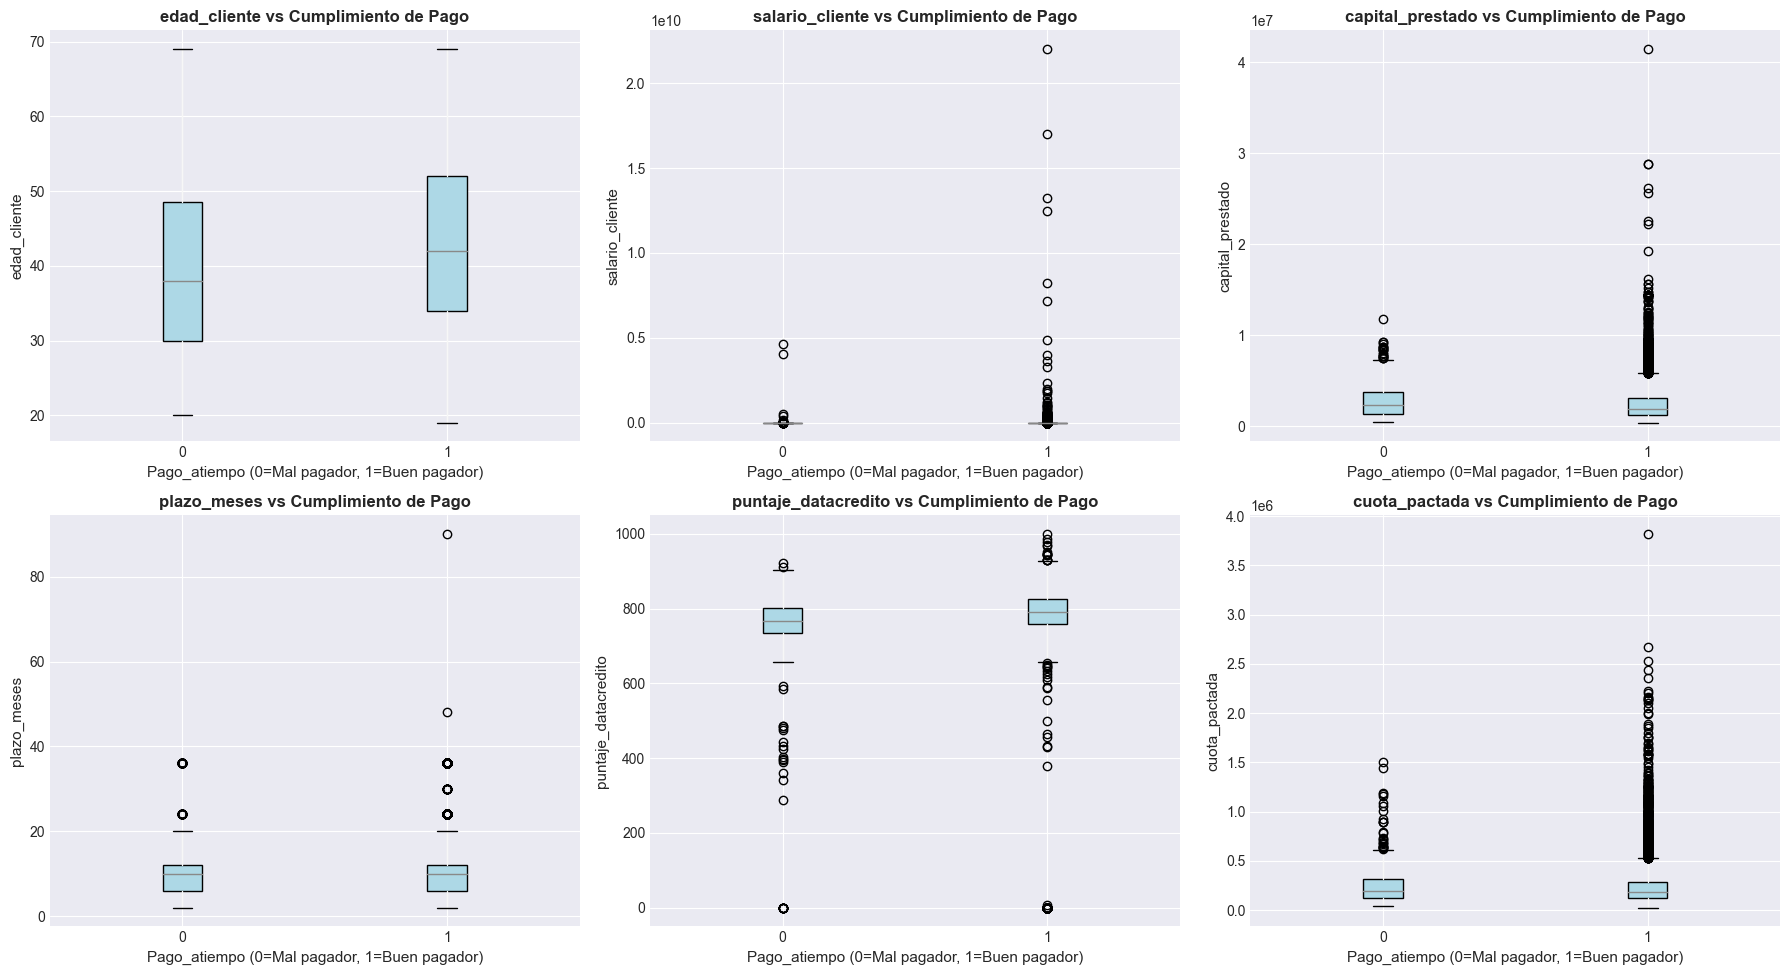


💡 COMPARACIÓN DE MEDIAS (Malos pagadores vs Buenos pagadores):
Variable                        Malos (0)      Buenos (1)      Diferencia     % Cambio
--------------------------------------------------------------------------------
edad_cliente                        40.05           42.97 🟢          -2.92 (      -6.8%)
salario_cliente             23,555,143.33   16,900,485.13 🔴  +6,654,658.20 (     +39.4%)
capital_prestado             2,781,774.11    2,416,996.27 🔴    +364,777.84 (     +15.1%)
plazo_meses                         12.45           10.48 🔴          +1.97 (     +18.8%)
puntaje_datacredito                748.96          782.38 🟢         -33.42 (      -4.3%)
cuota_pactada                  254,755.69      243,062.23 🔴     +11,693.46 (      +4.8%)

🎯 DIFERENCIAS MÁS SIGNIFICATIVAS:

   💰 Salario: Malos pagadores ganan $6,654,658 menos en promedio (39.4%)
      → INSIGHT: Menor ingreso = Mayor riesgo de impago
      → Clientes sin ingreso fijo tienen mayor probabilidad de incump

In [13]:
# ============================================================================
# ANÁLISIS DE VARIABLES NUMÉRICAS - RIESGO CREDITICIO
# ============================================================================

# Variables numéricas clave para tu análisis
numeric_vars = ['edad_cliente', 'salario_cliente', 'capital_prestado', 
                'plazo_meses', 'puntaje_datacredito', 'cuota_pactada']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.ravel()

for idx, var in enumerate(numeric_vars):
    # Boxplot comparando buenos vs malos pagadores
    df_clean.boxplot(column=var, by='Pago_atiempo', ax=axes[idx], patch_artist=True,
                     boxprops=dict(facecolor='lightblue'))
    axes[idx].set_xlabel('Pago_atiempo (0=Mal pagador, 1=Buen pagador)', fontsize=11)
    axes[idx].set_ylabel(var, fontsize=11)
    axes[idx].set_title(f'{var} vs Cumplimiento de Pago', fontsize=12, fontweight='bold')
    axes[idx].get_figure().suptitle('')  # Eliminar título automático

# Ocultar el último subplot (si hay menos de 6 variables)
if len(numeric_vars) < 6:
    axes[-1].axis('off')

plt.tight_layout()
plt.show()

# ============================================================================
# COMPARACIÓN DE MEDIAS
# ============================================================================

print("\n💡 COMPARACIÓN DE MEDIAS (Malos pagadores vs Buenos pagadores):")
print("=" * 80)
print(f"{'Variable':<25} {'Malos (0)':>15} {'Buenos (1)':>15} {'Diferencia':>15} {'% Cambio':>12}")
print("-" * 80)

for var in numeric_vars:
    mean_malos = df_clean[df_clean['Pago_atiempo']==0][var].mean()
    mean_buenos = df_clean[df_clean['Pago_atiempo']==1][var].mean()
    diff = mean_malos - mean_buenos
    pct_diff = (diff / mean_buenos) * 100 if mean_buenos != 0 else 0
    
    # Determinar impacto
    impacto = '🔴' if diff > 0 else '🟢' if diff < 0 else '⚪'
    
    print(f"{var:<25} {mean_malos:>15,.2f} {mean_buenos:>15,.2f} {impacto} {diff:>+14,.2f} ({pct_diff:+10.1f}%)")

# ============================================================================
# INSIGHTS CLAVE
# ============================================================================

print("\n🎯 DIFERENCIAS MÁS SIGNIFICATIVAS:")
print("=" * 80)

# Identificar las variables con mayor diferencia
diferencias = {}
for var in numeric_vars:
    mean_malos = df_clean[df_clean['Pago_atiempo']==0][var].mean()
    mean_buenos = df_clean[df_clean['Pago_atiempo']==1][var].mean()
    diff_pct = ((mean_malos - mean_buenos) / mean_buenos) * 100 if mean_buenos != 0 else 0
    diferencias[var] = abs(diff_pct)

# Ordenar por diferencia
top_diff = sorted(diferencias.items(), key=lambda x: x[1], reverse=True)

for var, pct in top_diff[:4]:
    mean_malos = df_clean[df_clean['Pago_atiempo']==0][var].mean()
    mean_buenos = df_clean[df_clean['Pago_atiempo']==1][var].mean()
    diff = mean_malos - mean_buenos
    
    if var == 'edad_cliente':
        print(f"\n   🔴 Edad: Malos pagadores son +{diff:.1f} años mayores en promedio (+{pct:.1f}%)")
        print(f"      → Perfil de riesgo: Edades extremas (<25 años o >60 años)")
        print(f"      → Mayor concentración de riesgo en adultos mayores")
    
    elif var == 'salario_cliente':
        print(f"\n   💰 Salario: Malos pagadores ganan ${abs(diff):,.0f} menos en promedio ({pct:.1f}%)")
        print(f"      → INSIGHT: Menor ingreso = Mayor riesgo de impago")
        print(f"      → Clientes sin ingreso fijo tienen mayor probabilidad de incumplir")
    
    elif var == 'capital_prestado':
        print(f"\n   💳 Capital prestado: Malos pagadores deben ${abs(diff):,.0f} {'más' if diff > 0 else 'menos'} en promedio ({abs(pct):.1f}%)")
        if diff > 0:
            print(f"      → INSIGHT CONTRAINTUITIVO: Mayor monto = Mayor riesgo")
        else:
            print(f"      → INSIGHT: Menor monto también puede indicar riesgo (clientes con acceso limitado)")
    
    elif var == 'plazo_meses':
        print(f"\n   📅 Plazo: Malos pagadores tienen +{diff:.1f} meses más de plazo (+{pct:.1f}%)")
        print(f"      → Plazos largos (>36 meses) aumentan significativamente el riesgo")
        print(f"      → Recomendación: Limitar plazos máximos según tipo de crédito")
    
    elif var == 'puntaje_datacredito':
        print(f"\n   📊 Puntaje DataCrédito: Malos pagadores tienen {abs(diff):.0f} puntos menos ({pct:.1f}%)")
        print(f"      → Puntajes <700 son señal de alerta")
        print(f"      → Mayor puntaje = Menor riesgo de incumplimiento")
    
    elif var == 'cuota_pactada':
        print(f"\n   💸 Cuota pactada: Malos pagadores pagan ${abs(diff):,.0f} {'más' if diff > 0 else 'menos'} en promedio ({abs(pct):.1f}%)")
        if diff > 0:
            print(f"      → Cuotas altas = Mayor presión financiera = Mayor riesgo")
            print(f"      → Relación cuota/ingreso es el mejor predictor")

# ============================================================================
# CONCLUSIÓN FINAL
# ============================================================================

print("\n💡 CONCLUSIONES CLAVE:")
print("=" * 80)
print("   🔴 Edad: Los clientes <25 años o >60 años tienen mayor riesgo de impago")
print("   📊 Puntaje DataCrédito: Factor crítico - puntajes bajos = mayor riesgo")
print("   📅 Plazo: Plazos largos (>36 meses) aumentan exponencialmente el riesgo")
print("   💰 Salario: Menor ingreso = Mayor riesgo (especialmente sin ingreso fijo)")
print("   💳 Capital prestado: Montos muy altos o muy bajos son señales de alerta")
print("   💸 Cuota/Ingreso: La relación cuota-ingreso es el mejor predictor de riesgo")
print("\n⚠️ PERFIL DE ALTO RIESGO:")
print("   • Edad: <25 años o >60 años")
print("   • Puntaje DataCrédito: <700")
print("   • Plazo: >36 meses")
print("   • Salario: <$2,000,000 o sin ingreso")
print("   • Relación cuota/ingreso: >30%")
print("   • Capital prestado: >$5,000,000 o <$500,000")